In [1]:
import pandas as pd
from catrace.dataset import load_dataset_config

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [4]:
ob_dsconfig = load_dataset_config('../olfactory_bulb/juvenile_dataset_OB_without14mm_phearg.json')
dp_dsconfig = load_dataset_config('../juvenile_dataset_without14mm_phearg.json')

/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_learned detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type odors_novel detected when decoding DatasetConfig.
  warnings.warn(
/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/dataclasses_json/core.py:188: RuntimeWarning: 'NoneType' object value of non-optional type onsets detected when decoding DatasetConfig.
  warnings.warn(


In [5]:
from os.path import join as pjoin
regions = ['OB', 'Dp']
configs = [ob_dsconfig, dp_dsconfig]
metric = 'cosine'
window = [38, 63]#[37, 52]
window_tag = f'window_{window[0]}to{window[1]}'
region_dfs = {region: pd.read_pickle(pjoin(dsconfig.processed_trace_dir, metric, window_tag, 'cross_trial_similarity.pkl')) for region, dsconfig in zip(regions, configs)}
cross_trial_dff = pd.concat(region_dfs.values(), keys=region_dfs.keys(), names=['region', 'fish_id', 'condition'])
cross_trial_dff

odor                                             Phe       Phe       Phe  \
region fish_id                   condition                                 
OB     2021-07-15-DpOBEM-N2_OB   naive      0.035013  0.035138  0.031947   
       2021-07-16-DpOBEM-N3_OB   naive      0.033950  0.042504  0.040100   
       2021-12-10-DpOBEM-N4_OB   naive      0.032050  0.035379  0.028582   
       2021-12-31-DpOBEM-N7_OB   naive      0.023314  0.035133  0.029420   
       2022-02-13-DpOBEM-N10_OB  naive      0.021366  0.023936  0.026329   
...                                              ...       ...       ...   
Dp     2021-11-11-DpOBEM-JH23_Dp phe-trp    0.245631  0.253135  0.225521   
       2021-11-14-DpOBEM-JH23_Dp phe-trp    0.310969  0.412747  0.371826   
       2021-11-24-DpOBEM-JH24_Dp phe-trp    0.228173  0.286030  0.285090   
       2021-11-27-DpOBEM-JH24_Dp phe-trp    0.246682  0.296750  0.256860   
       2021-11-26-DpOBEM-JH24_Dp phe-trp    0.156866  0.301865  0.253712   

odor                                             Arg       Arg       Arg  \
region fish_id                   condition                                 
OB     2021-07-15-DpOBEM-N2_OB   naive      0.024523  0.030134  0.026093   
       2021-07-16-DpOBEM-N3_OB   naive      0.024173  0.029676  0.029769   
       2021-12-10-DpOBEM-N4_OB   naive      0.035180  0.034820  0.032401   
       2021-12-31-DpOBEM-N7_OB   naive      0.038807  0.042307  0.036475   
       2022-02-13-DpOBEM-N10_OB  naive      0.037648  0.056620  0.041790   
...                                              ...       ...       ...   
Dp     2021-11-11-DpOBEM-JH23_Dp phe-trp    0.166646  0.190644  0.162744   
       2021-11-14-DpOBEM-JH23_Dp phe-trp    0.285358  0.292987  0.313875   
       2021-11-24-DpOBEM-JH24_Dp phe-trp    0.239940  0.246494  0.235874   
       2021-11-27-DpOBEM-JH24_Dp phe-trp    0.252634  0.275034  0.214959   
       2021-11-26-DpOBEM-JH24_Dp phe-trp    0.155271  0.207489  0.195337   

odor                                             Trp       Trp       Trp  \
region fish_id                   condition                                 
OB     2021-07-15-DpOBEM-N2_OB   naive      0.045439  0.043467  0.037773   
       2021-07-16-DpOBEM-N3_OB   naive      0.047667  0.056360  0.042128   
       2021-12-10-DpOBEM-N4_OB   naive      0.036394  0.036969  0.031382   
       2021-12-31-DpOBEM-N7_OB   naive      0.044074  0.050680  0.045100   
       2022-02-13-DpOBEM-N10_OB  naive      0.041022  0.043556  0.037364   
...                                              ...       ...       ...   
Dp     2021-11-11-DpOBEM-JH23_Dp phe-trp    0.429121  0.462885  0.314642   
       2021-11-14-DpOBEM-JH23_Dp phe-trp    0.325741  0.420690  0.370269   
       2021-11-24-DpOBEM-JH24_Dp phe-trp    0.312613  0.376719  0.378358   
       2021-11-27-DpOBEM-JH24_Dp phe-trp    0.252145  0.278835  0.278626   
       2021-11-26-DpOBEM-JH24_Dp phe-trp    0.163738  0.252560  0.247520   

odor                                            TDCA      TDCA      TDCA  \
region fish_id                   condition                                 
OB     2021-07-15-DpOBEM-N2_OB   naive      0.046433  0.045629  0.039414   
       2021-07-16-DpOBEM-N3_OB   naive      0.041213  0.047269  0.048682   
       2021-12-10-DpOBEM-N4_OB   naive      0.032842  0.037200  0.040840   
       2021-12-31-DpOBEM-N7_OB   naive      0.022802  0.024824  0.020755   
       2022-02-13-DpOBEM-N10_OB  naive      0.031341  0.037436  0.029509   
...                                              ...       ...       ...   
Dp     2021-11-11-DpOBEM-JH23_Dp phe-trp    0.357002  0.418785  0.304479   
       2021-11-14-DpOBEM-JH23_Dp phe-trp    0.407559  0.422805  0.467358   
       2021-11-24-DpOBEM-JH24_Dp phe-trp    0.414155  0.430028  0.397876   
       2021-11-27-DpOBEM-JH24_Dp phe-trp    0.367908  0.373260  0.323156   
       2021-11-26-DpOBEM-JH24_Dp phe-trp    0.218066  0.296363  0.203472   

odor                                        

In [6]:
from scipy import stats

# Filter out naive fish
df_filtered = cross_trial_dff.xs('naive', level='condition')
# Filter so that fish_id is not in exp_14mm
#df_filtered = df_filtered[~df_filtered.index.get_level_values('fish_id').isin(exp_14mm)]
# Compare values from OB to values from Dp
df_dp = df_filtered.xs('Dp', level='region')
df_ob = df_filtered.xs('OB', level='region')

# Flatten the DataFrames
flattened_dp = pd.DataFrame(df_dp.values.flatten(), columns=['value'])
flattened_dp['region'] = 'Dp'

flattened_ob = pd.DataFrame(df_ob.values.flatten(), columns=['value'])
flattened_ob['region'] = 'OB'

# Combine the DataFrames
datadf = pd.concat([flattened_dp, flattened_ob], ignore_index=True)

# Assign appropriate column names for plotting
datadf.columns = ['value', 'region']

# Perform the t-test
# test_func = stats.ttest_ind
# kywargs = {'equal_var': False}
test_func = stats.mannwhitneyu
kywargs = {}
t_stat, p_value = test_func(flattened_dp['value'], flattened_ob['value'], **kywargs)

# Prepare the test results
test_results = {
    ('Dp', 'OB'): {'t_stat': t_stat, 'p_value': p_value}
}

print(test_results)

{('Dp', 'OB'): {'t_stat': 11664.0, 'p_value': 6.107033802324049e-37}}


In [7]:
'region' in datadf.columns

True

In [8]:
from catrace.stats import apply_test_pair
test_results = apply_test_pair(datadf, yname='value', group_name1='Dp', group_name2='OB', test_type='mannwhitneyu', condition_name='region')

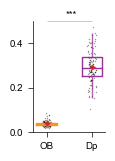

In [9]:
from catrace.visualize import plot_boxplot_with_significance, PlotBoxplotParams
# Define parameters for the plot
xname = 'region'
yname = 'value'
if metric == 'pattern_correlation':
    ylabel = 'Trial-to-trial similarity'
elif metric == 'cosine':
    ylabel = 'Trial-to-trial cosine distance'
else:
    ylabel = metric
test_type = 'pairwise'
ref_key = 'OB'  # Use 'OB' as the reference category

ylim = (0, 0.5)
hline_y = 0
show_ns = True
pvalue_marker_xoffset = 0.01
box_colors = ['#f6921e', '#90278e']

params = PlotBoxplotParams(figsize=(1.4,1.65),
                           box_colors=box_colors,
                           box_linewidth=1)

# Plot the boxplot with significance annotations
fig, ax = plot_boxplot_with_significance(datadf, xname, yname, ylabel,
                                         test_results, test_type=test_type, 
                                         ref_key=ref_key, x_order=['OB', 'Dp'],
                                         show_ns=show_ns, 
                                         **params.to_dict())

from catrace.visualize import set_yticks_interval
set_yticks_interval(ax, 0.2)

ax.set_ylim(ylim)

# Set ylabel to empty
ax.set_ylabel('')
from catrace.for_paper import save_figure_for_paper, save_stats_json
dataset_name = 'juvenile'
fig_name = f'trial_to_trial_similarity_boxplot_{dataset_name}_{metric}_{window_tag}'
paper_fig_dir = '/tungstenfs/scratch/gfriedri/hubo/Dp_manifold/figures_for_paper'

save_figure_for_paper(fig, fig_name, paper_fig_dir)
save_stats_json(test_results, fig_name, paper_fig_dir, tuple_key_to_str=True)


In [10]:
from catrace.stats import format_test_results_pair
sentence = format_test_results_pair(test_results)
print(sentence)

Comparing Dp (mean = 0.2941 ± 0.07201, n = 108) vs OB (mean = 0.03961 ± 0.01187, n = 108): Mann–Whitney U test, U = 11664.00, P = 6.1 × 10^-37.
